In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [5]:
from sklearn.preprocessing import StandardScaler

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
df = pd.read_csv(r"C:\Users\User\Downloads\pima_diabetes_data.csv")
print(df.head())   #Load Dataset.

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [8]:
# Basic exploration
print("Shape:", df.shape)            # rows and columns
print("\nFirst 5 rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)
print("\nBasic statistics:")
print(df.describe())

Shape: (768, 9)

First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Data types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age    

In [9]:
# Check missing values
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [10]:
# Dataset info
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [11]:
# Check class balance
print("\nTarget distribution:")
print(df['Outcome'].value_counts())


Target distribution:
Outcome
0    500
1    268
Name: count, dtype: int64


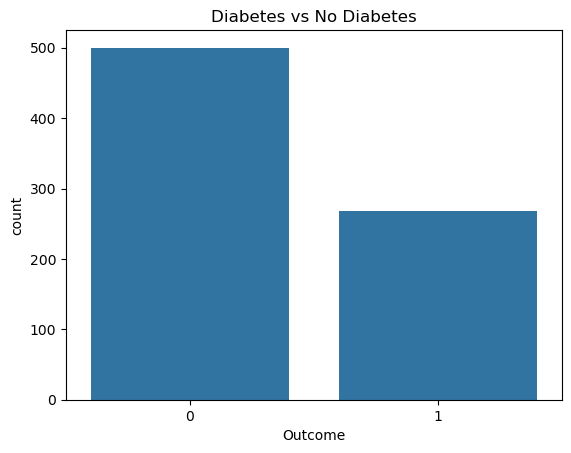

In [12]:
# Visualize class balance
sns.countplot(x='Outcome', data=df)
plt.title('Diabetes vs No Diabetes')
plt.savefig('class_balance.png')
plt.show()

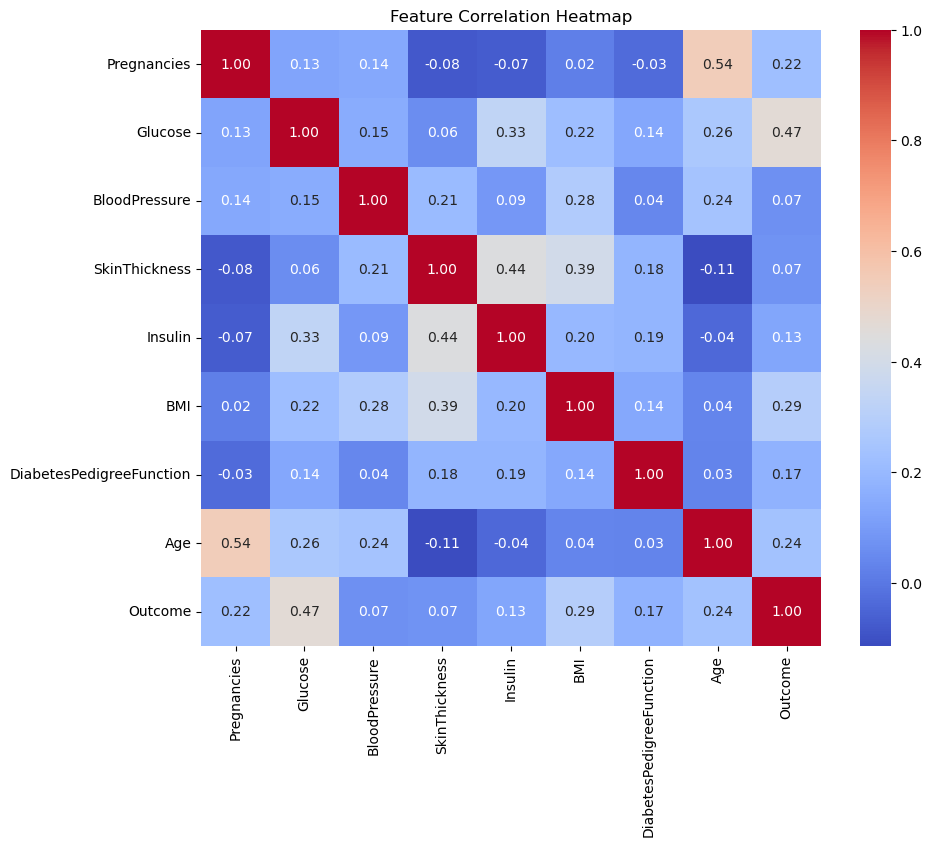

In [13]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.savefig('correlation.png')
plt.show()

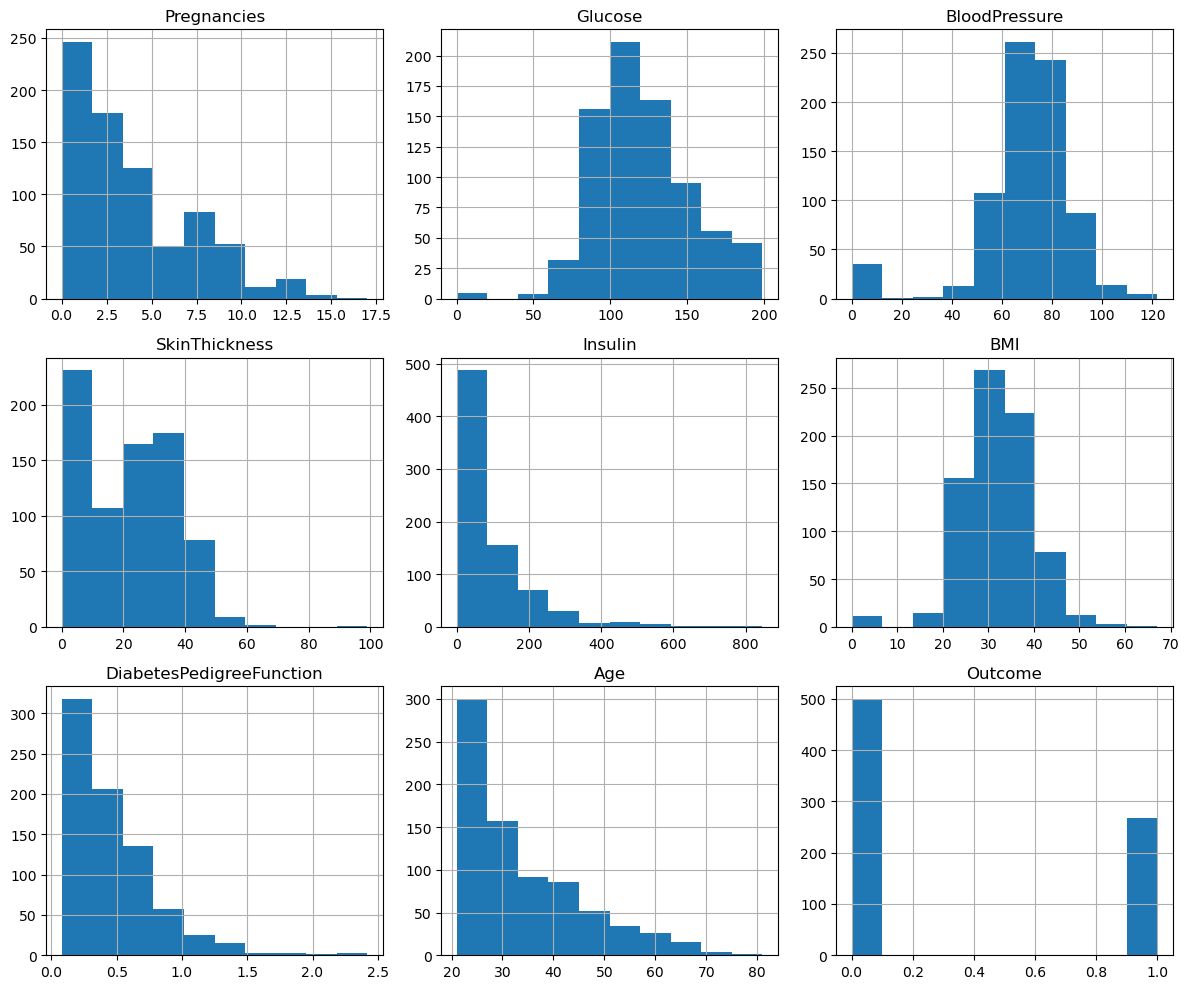

In [14]:
# Histograms for all features
df.hist(figsize=(12, 10))
plt.tight_layout()
plt.savefig('histograms.png')
plt.show()

In [15]:
# ===== Handle zero values (they are actually missing) =====
# Columns where 0 is biologically impossible
zero_not_valid = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

In [16]:
for col in zero_not_valid:
    print(f"{col} - zeros: {(df[col] == 0).sum()}")
    df[col] = df[col].replace(0, np.nan)   # replace 0 with NaN

Glucose - zeros: 5
BloodPressure - zeros: 35
SkinThickness - zeros: 227
Insulin - zeros: 374
BMI - zeros: 11


In [17]:
# Fill missing values with median (FIXED)
for col in zero_not_valid:
    df[col] = df[col].fillna(df[col].median())

print("\nAfter handling zeros - missing values:")
print(df.isnull().sum())


After handling zeros - missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [18]:
# ===== SPLIT features and target =====
X = df.drop('Outcome', axis=1)   # features
y = df['Outcome']                 # target


In [19]:
# ===== SCALE features =====
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [20]:
# ===== TRAIN/TEST SPLIT =====
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")


Training set size: 614 samples
Test set size: 154 samples


In [21]:
# ===== STEP 4: FEATURE ENGINEERING =====

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA

In [22]:
# ===== Feature Selection using SelectKBest =====
selector = SelectKBest(score_func=f_classif, k=5)
X_selected = selector.fit_transform(X_scaled, y)

In [23]:
# Show feature scores
feature_scores = pd.DataFrame({
    'Feature': df.drop('Outcome', axis=1).columns,
    'Score': selector.scores_
}).sort_values('Score', ascending=False)

print("Feature importance scores:")
print(feature_scores)

Feature importance scores:
                    Feature       Score
1                   Glucose  245.667855
5                       BMI   82.629271
7                       Age   46.140611
0               Pregnancies   39.670227
3             SkinThickness   37.078538
4                   Insulin   33.190796
6  DiabetesPedigreeFunction   23.871300
2             BloodPressure   21.631580


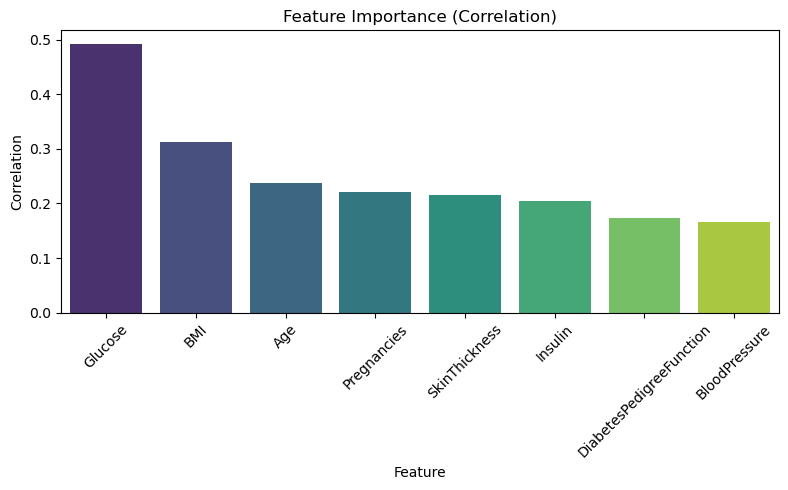

In [24]:
# Feature importance (correlation)
feature_corr = df.corr()['Outcome'].drop('Outcome').sort_values(ascending=False)

feature_corr_df = feature_corr.reset_index()
feature_corr_df.columns = ['Feature', 'Score']

plt.figure(figsize=(8,5))

sns.barplot(
    x='Feature',        
    y='Score',          
    hue='Feature',      
    data=feature_corr_df,
    palette='viridis',
    legend=False
)

plt.title('Feature Importance (Correlation)')
plt.xlabel('Feature')
plt.ylabel('Correlation')

plt.xticks(rotation=45)   
plt.tight_layout()
plt.show()

In [25]:
# ===== STEP 5: MODEL TRAINING =====

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

In [26]:
# Logistic Regression (basic model)
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [27]:
from sklearn.metrics import accuracy_score

# Predictions
y_pred = lr.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7012987012987013


In [28]:
# KNN (distance-based model)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [29]:
from sklearn.metrics import accuracy_score

# Predict on test data
y_pred = knn.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7532467532467533


In [30]:
# SVM (distance-based model)
svm = SVC(kernel='rbf', random_state=42, probability=True)
svm.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [31]:
from sklearn.metrics import accuracy_score

# Predict on test data
y_pred = svm.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("SVM Accuracy:", accuracy)

SVM Accuracy: 0.7337662337662337


In [32]:
# Random Forest (ensemble model)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [33]:
from sklearn.metrics import accuracy_score

# Predict on test data
y_pred = rf.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Random Forest Accuracy:", accuracy)

Random Forest Accuracy: 0.7792207792207793


In [34]:
# ===== STEP 6: HYPERPARAMETER TUNING =====

from sklearn.model_selection import GridSearchCV

# ---- Tune Random Forest ----
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,              # 5-fold cross validation
    scoring='accuracy',
    n_jobs=-1          # use all CPU cores
)
rf_grid.fit(X_train, y_train)

print("Best RF parameters:", rf_grid.best_params_)
print("Best CV score:", rf_grid.best_score_)

Best RF parameters: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50}
Best CV score: 0.7736505397840863


In [35]:
# ---- Tune KNN ----
knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance']
}

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    knn_params,
    cv=5,
    scoring='accuracy'
)
knn_grid.fit(X_train, y_train)

print("\nBest KNN parameters:", knn_grid.best_params_)
print("Best CV score:", knn_grid.best_score_)


Best KNN parameters: {'n_neighbors': 11, 'weights': 'distance'}
Best CV score: 0.7638544582167134


In [36]:

# Use the best models
best_rf = rf_grid.best_estimator_
best_knn = knn_grid.best_estimator_

In [37]:
# ===== STEP 7: MODEL EVALUATION =====

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns

models = {
    'Logistic Regression': lr,
    'KNN (tuned)': best_knn,
    'SVM': svm,
    'Random Forest (tuned)': best_rf
}

results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    }
    print(f"\n===== {name} =====")
    print(classification_report(y_test, y_pred))



===== Logistic Regression =====
              precision    recall  f1-score   support

           0       0.75      0.81      0.78       100
           1       0.59      0.50      0.54        54

    accuracy                           0.70       154
   macro avg       0.67      0.66      0.66       154
weighted avg       0.69      0.70      0.70       154


===== KNN (tuned) =====
              precision    recall  f1-score   support

           0       0.78      0.82      0.80       100
           1       0.63      0.57      0.60        54

    accuracy                           0.73       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.73      0.73       154


===== SVM =====
              precision    recall  f1-score   support

           0       0.77      0.84      0.80       100
           1       0.64      0.54      0.59        54

    accuracy                           0.73       154
   macro avg       0.71      0.69      0.69       154

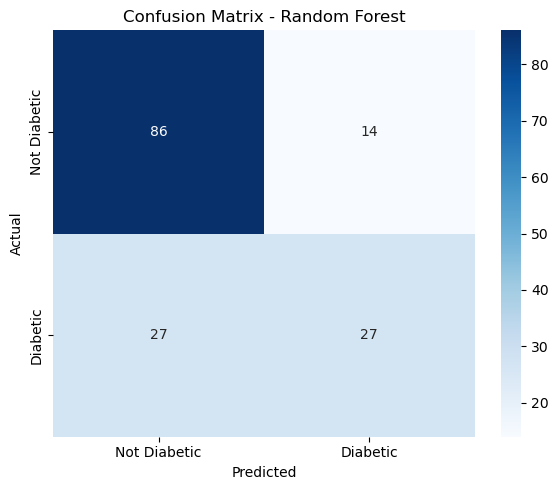

In [38]:
# ---- Confusion Matrix for best model (Random Forest) ----
y_pred_rf = best_rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Diabetic', 'Diabetic'],
            yticklabels=['Not Diabetic', 'Diabetic'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()


Model Comparison:
                       Accuracy  Precision  Recall  F1-Score
Logistic Regression      0.7013     0.5870  0.5000    0.5400
KNN (tuned)              0.7338     0.6327  0.5741    0.6019
SVM                      0.7338     0.6444  0.5370    0.5859
Random Forest (tuned)    0.7338     0.6585  0.5000    0.5684


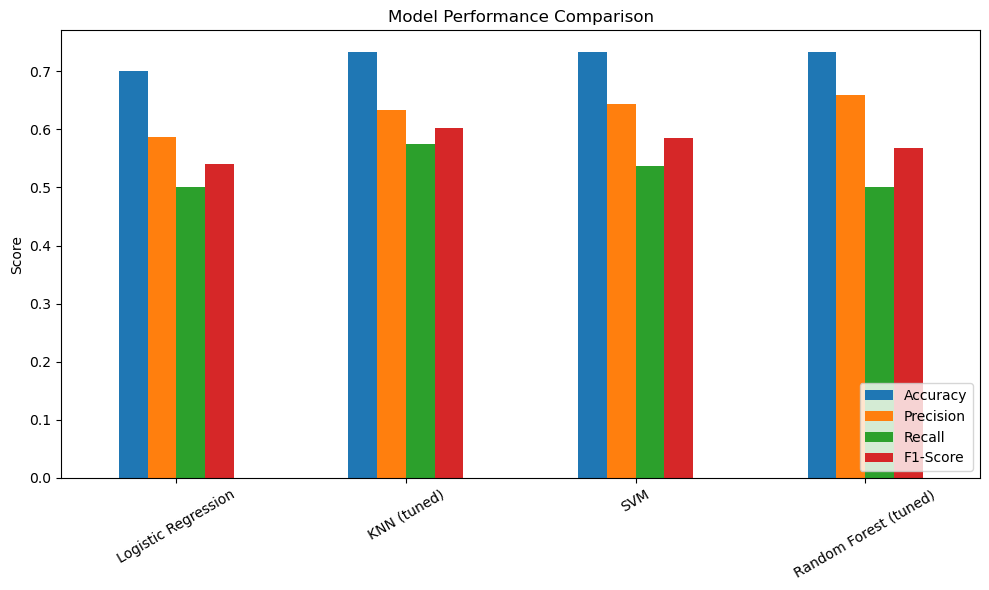

In [39]:
# ===== STEP 8: MODEL COMPARISON =====

results_df = pd.DataFrame(results).T
print("\nModel Comparison:")
print(results_df.round(4))

# Bar chart comparison
results_df.plot(kind='bar', figsize=(10, 6))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=30)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('model_comparison.png')
plt.show()

In [40]:
# ===== STEP 9: DEPLOYMENT - PREDICTION APP =====

import pickle
import numpy as np

# First, save the trained model and scaler
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_rf, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Model and scaler saved successfully!")

# ===== PREDICTION FUNCTION =====
def predict_diabetes():
    print("\n" + "="*50)
    print("  DIABETES RISK PREDICTION TOOL")
    print("="*50)
    print("Please enter the following patient details:\n")

    try:
        pregnancies = float(input("Number of pregnancies: "))
        glucose = float(input("Glucose level (mg/dL): "))
        blood_pressure = float(input("Blood pressure (mm Hg): "))
        skin_thickness = float(input("Skin thickness (mm): "))
        insulin = float(input("Insulin level (mu U/ml): "))
        bmi = float(input("BMI (weight in kg / height in m²): "))
        dpf = float(input("Diabetes pedigree function (e.g. 0.5): "))
        age = float(input("Age (years): "))

        # Prepare input
        input_data = np.array([[pregnancies, glucose, blood_pressure,
                                  skin_thickness, insulin, bmi, dpf, age]])

        # Load scaler and scale the input
        with open('scaler.pkl', 'rb') as f:
            loaded_scaler = pickle.load(f)
        input_scaled = loaded_scaler.transform(input_data)

        # Load model and predict
        with open('best_model.pkl', 'rb') as f:
            loaded_model = pickle.load(f)
        prediction = loaded_model.predict(input_scaled)[0]
        probability = loaded_model.predict_proba(input_scaled)[0][1]

        print("\n" + "="*50)
        print("           PREDICTION RESULT")
        print("="*50)
        if prediction == 1:
            print(f"  Result: HIGH RISK - Diabetic")
            print(f"  Probability of diabetes: {probability*100:.1f}%")
            print("  Recommendation: Please consult a doctor.")
        else:
            print(f"  Result: LOW RISK - Not Diabetic")
            print(f"  Probability of diabetes: {probability*100:.1f}%")
            print("  Recommendation: Maintain a healthy lifestyle.")
        print("="*50)

    except ValueError:
        print("Invalid input. Please enter numeric values.")

# Run the app
predict_diabetes()

Model and scaler saved successfully!

  DIABETES RISK PREDICTION TOOL
Please enter the following patient details:



Number of pregnancies:  3
Glucose level (mg/dL):  89
Blood pressure (mm Hg):  134
Skin thickness (mm):  45
Insulin level (mu U/ml):  35
BMI (weight in kg / height in m²):  23
Diabetes pedigree function (e.g. 0.5):  0.7
Age (years):  29



           PREDICTION RESULT
  Result: LOW RISK - Not Diabetic
  Probability of diabetes: 17.5%
  Recommendation: Maintain a healthy lifestyle.


C:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
